In [2]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
data = Path("data")

In [4]:
datafiler = os.listdir(data)
datafiler.sort()
datafiler

['.ipynb_checkpoints',
 'barnetallsfordeling.csv',
 'befolkningsutvikling_2023_2058_1_1.csv',
 'befolkningsutvikling_2023_2058_1_5.csv',
 'befolkningsutvikling_2023_2058_2_1.csv',
 'befolkningsutvikling_2023_2063_1_5.csv',
 'befolkningsutvikling_2063_2113_1_1.csv',
 'befolkningsutvikling_2063_2113_1_5.csv',
 'befolkningsutvikling_2063_2113_2_1.csv',
 'popfordeling_2023-2058_tfr1_1.csv',
 'popfordeling_2023-2058_tfr1_5.csv',
 'popfordeling_2023-2058_tfr2_1.csv',
 'popfordeling_2023-2063_tfr1_5.csv',
 'popfordeling_2023-2123_tfr1_5.csv',
 'popfordeling_2063-2113_tfr1_1.csv',
 'popfordeling_2063-2113_tfr1_5.csv',
 'popfordeling_2063-2113_tfr2_1.csv',
 'populasjon_2058_tfr1_1.csv',
 'populasjon_2058_tfr1_5.csv',
 'populasjon_2058_tfr2_1.csv',
 'populasjon_2063_tfr1_5.csv',
 'populasjon_2113_tfr1_1.csv',
 'populasjon_2113_tfr1_5.csv',
 'populasjon_2113_tfr2_1.csv',
 'populasjon_2123_tfr1_5.csv',
 'startpop_no.csv',
 'startpop_no_test.csv']

In [5]:
aktuelle_aar = 2058
aar = 2025
alder = 27
print(f"I året {aktuelle_aar} er jeg {aktuelle_aar - aar + alder} år gammel")

I året 2058 er jeg 60 år gammel


In [6]:
befolkning_23_63 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_5.csv")#.iloc[:,1:]
befolkning_23_63.tail(5)

,år,pop_1.5
31,2054,5553691
32,2055,5540264
33,2056,5524199
34,2057,5505572
35,2058,5484465


In [7]:
befolkning_63_23_1_5 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_5.csv")#.iloc[:,1:]
befolkning_63_23_2_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_2_1.csv")#.iloc[:,1:]
befolkning_63_23_1_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_1.csv")#.iloc[:,1:]

befolkning_63_23_1_5.head(5)

,år,pop_1.5
0,2023,5488984
1,2024,5498949
2,2025,5508419
3,2026,5517069
4,2027,5525174


In [8]:
befolkning = befolkning_63_23_1_5.merge(befolkning_63_23_2_1, on ="år", how="left").merge(befolkning_63_23_1_1, on ="år", how="left")

In [19]:
befolkning_til_nå = pd.read_csv("data/befolkning.csv").iloc[:-1,]
befolkning_til_nå.head()

,år,pop
0,1986,4159187
1,1987,4175521
2,1988,4198289
3,1989,4220686
4,1990,4233116


In [27]:
befolkning_til_nå.loc[lambda x: x.år == 2023]["pop"]

37    5488984
Name: pop, dtype: int64

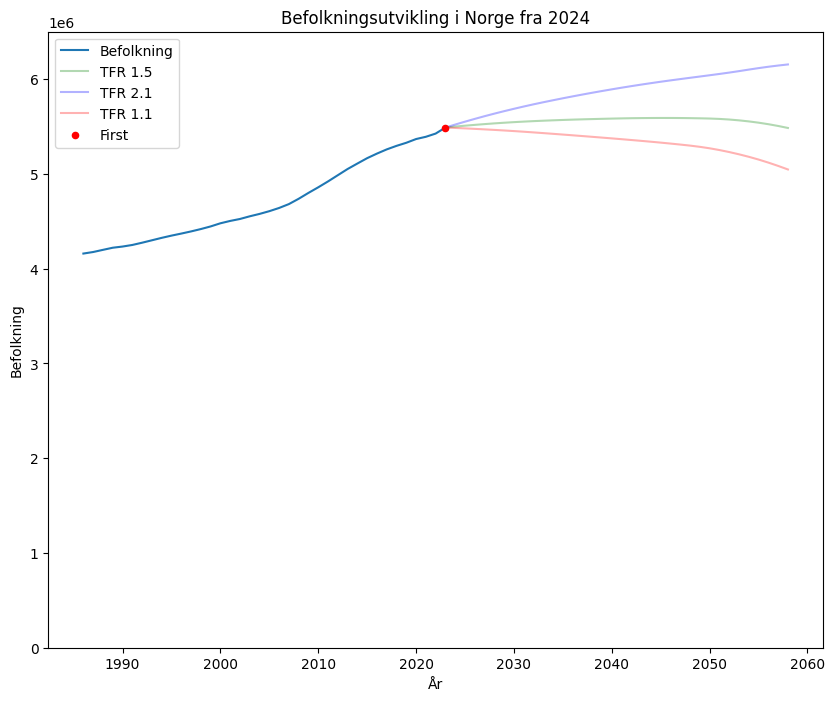

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(befolkning_til_nå.år, befolkning_til_nå["pop"], label='Befolkning')
ax.plot(befolkning.år, befolkning["pop_1.5"], color='green', alpha = 0.3, label='TFR 1.5')
ax.plot(befolkning.år, befolkning["pop_2.1"], color='blue', alpha = 0.3, label='TFR 2.1')
ax.plot(befolkning.år, befolkning["pop_1.1"], color='red', alpha = 0.3, label='TFR 1.1')
plt.scatter(x=2023, y=befolkning_til_nå.loc[lambda x: x.år == 2023]["pop"], color="red", s = 20, zorder = 5, label = "First")



ax.set_ylim(0,65e5)
ax.set_ylabel('Befolkning')
ax.set_xlabel('År')
ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()

# ax.line()

In [33]:
befolkning["pop_2023"] = befolkning_til_nå.loc[lambda x: x.år == 2023]["pop"].values[0]

In [36]:
befolkning = befolkning.assign(
    pop_1_5_endring = lambda x: x["pop_1.5"] - x["pop_2023"],
    pop_2_endring = lambda x: x["pop_2.1"] - x["pop_2023"],
    pop_1_1_endring = lambda x: x["pop_1.1"] - x["pop_2023"],
)
befolkning

,år,pop_1.5,pop_2.1,pop_1.1,pop_2023,pop_1_5_endring,pop_2_endring,pop_1_1_endring
0,2023,5488984,5488984,5488984,5488984,0,0,0
1,2024,5498949,5520436,5484682,5488984,9965,31452,-4302
2,2025,5508419,5550894,5480111,5488984,19435,61910,-8873
3,2026,5517069,5580271,5474995,5488984,28085,91287,-13989
4,2027,5525174,5608620,5469617,5488984,36190,119636,-19367
5,2028,5532794,5635751,5464000,5488984,43810,146767,-24984
6,2029,5539658,5661724,5457967,5488984,50674,172740,-31017
7,2030,5545904,5686663,5451602,5488984,56920,197679,-37382
8,2031,5551491,5710724,5444821,5488984,62507,221740,-44163
9,2032,5556558,5733794,5437630,5488984,67574,244810,-51354


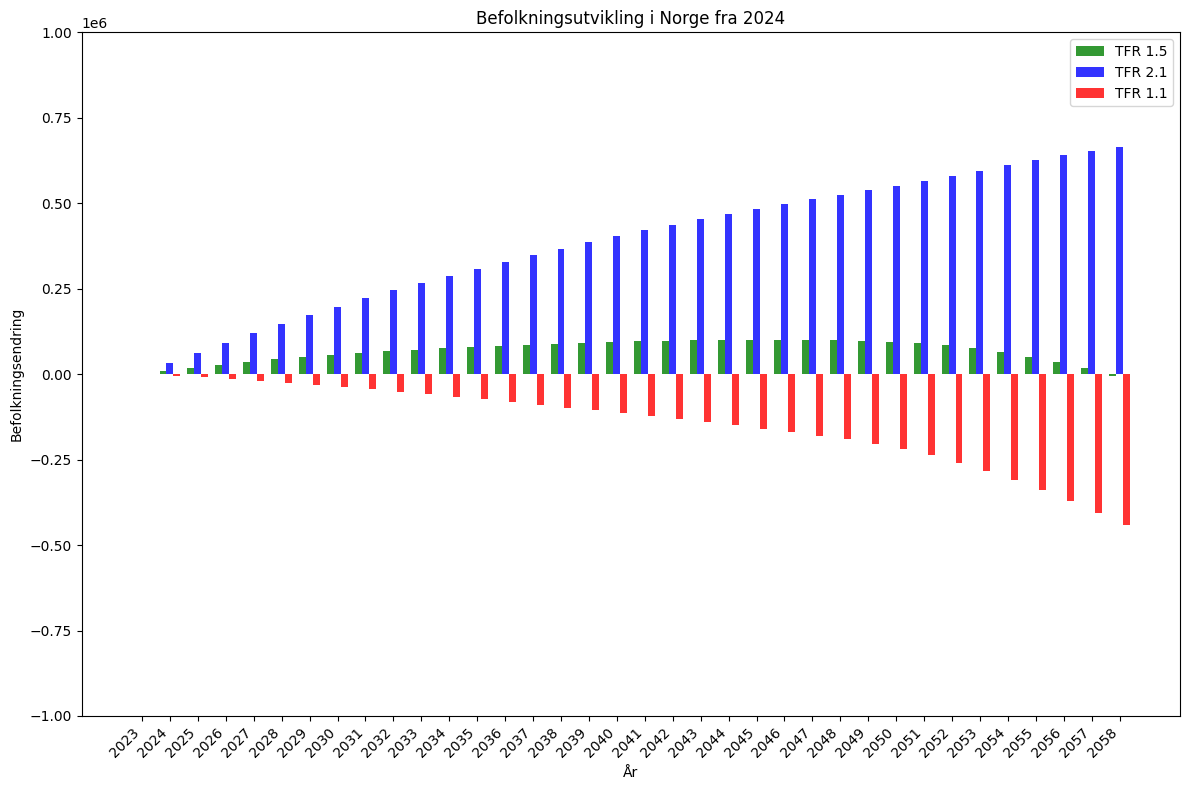

In [49]:
import numpy as np

width = 0.25 # Width of the bars

x = np.arange(len(befolkning.år)) # the label locations

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(x - width, befolkning["pop_1_5_endring"], width, color='green', alpha=0.8, label='TFR 1.5')
ax.bar(x, befolkning["pop_2_endring"], width, color='blue', alpha=0.8, label='TFR 2.1')
ax.bar(x + width, befolkning["pop_1_1_endring"], width, color='red', alpha=0.8, label='TFR 1.1')

ax.set_ylim(-1e6, 10e5)
ax.set_ylabel('Befolkningsendring')
ax.set_xlabel('År')
ax.set_xticks(x)
ax.set_xticklabels(befolkning.år, rotation=45, ha='right')

ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()
plt.tight_layout()

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(befolkningsutvikling.år, befolkningsutvikling["pop_1.5"]) 
plt.plot(df1['år'], df1['pop'], label='1986-2024', color='blue')

for col in ny_befolkning_etter.columns:
    if col != "år":
        plt.plot(ny_befolkning_etter.år, ny_befolkning_etter[col], label = f"TFR = {col}")


plt.xlabel('År')
plt.ylabel('Befolkning')
plt.scatter(x=2025, y= befolkningsutvikling.loc[lambda x: x.år == 2025]["pop_1.5"], color="red", s = 20, zorder = 5, label = "Første fremskrivning med TFR = 1.4")
plt.legend()
plt.ylim(0, 6.5e6)
#plt.grid(True)
plt.show()

NameError: name 'befolkningsutvikling' is not defined

<Figure size 1000x600 with 0 Axes>

<Axes: title={'center': 'Befolkning 2035'}>

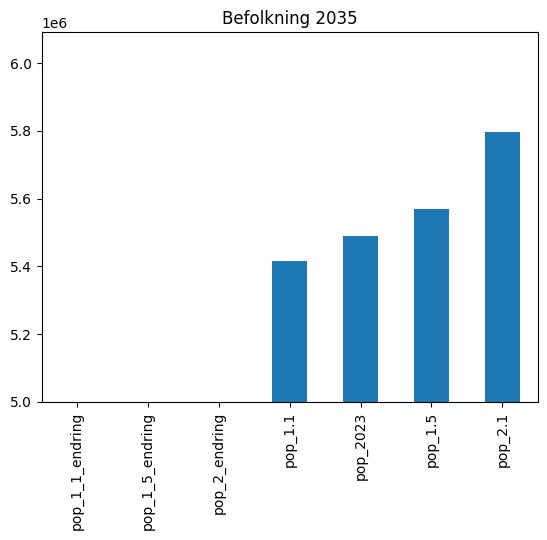

In [51]:
befolkning.set_index("år").loc[2035].sort_values().plot(kind="bar", ylim=(5e6, None), title="Befolkning 2035")


In [52]:
populasjon_2113_1_5 = pd.read_csv(data / f'populasjon_{aktuelle_aar}_tfr1_5.csv')
populasjon_2113_1_1 = pd.read_csv(data / f'populasjon_{aktuelle_aar}_tfr1_1.csv')
populasjon_2113_2_1 = pd.read_csv(data / f'populasjon_{aktuelle_aar}_tfr2_1.csv')


In [53]:
populasjon_2113_1_5

,sex,alder,barn
0,M,35.0,2.0
1,M,35.0,3.0
2,M,35.0,0.0
3,M,35.0,0.0
4,M,35.0,2.0
...,...,...,...
5484460,K,0.0,0.0
5484461,M,0.0,0.0
5484462,K,0.0,0.0
5484463,M,0.0,0.0


<Axes: xlabel='barn'>

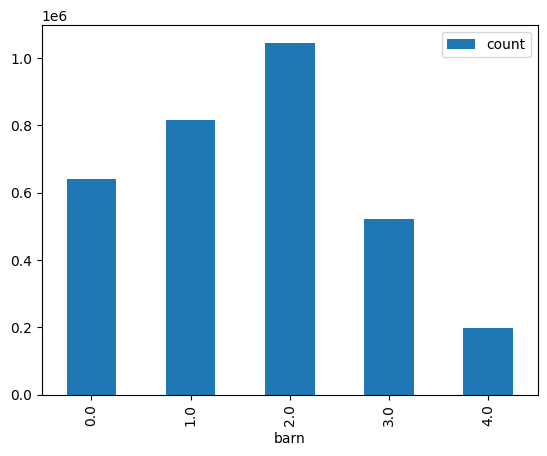

In [54]:
populasjon_2113_1_5.loc[lambda x: (x.alder > 45)].barn.value_counts().sort_index().reset_index().plot( x="barn", y="count", kind="bar")

<Axes: xlabel='barn'>

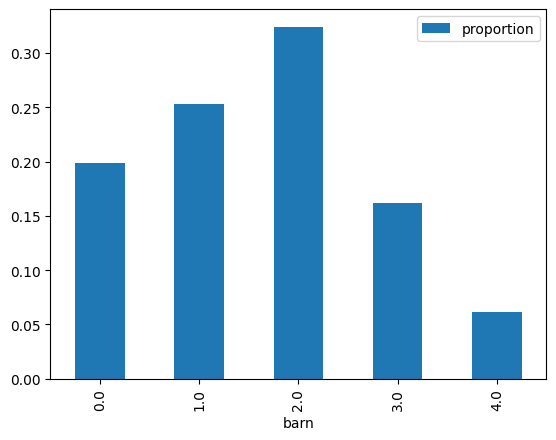

In [55]:
populasjon_2113_1_5.loc[lambda x: (x.alder > 45)].barn.value_counts(normalize=True).sort_index().reset_index().plot( x="barn", y="proportion", kind="bar")

In [56]:
populasjon_2113_1_5.loc[lambda x: (x.alder > 45)].barn.value_counts(normalize=True).sort_index().reset_index()

,barn,proportion
0,0.0,0.198692
1,1.0,0.253557
2,2.0,0.324301
3,3.0,0.161790
4,4.0,0.061659


In [77]:
import altair as alt

df = populasjon_2113_1_5.loc[lambda x: (x.alder > 45)].barn.value_counts(normalize=True).sort_index().reset_index()
# 2. Create the Stacking Groups
def get_group(barn):
    """Categorizes the original child counts into the requested groups."""
    if barn in [0.0, 1.0]:
        return '0-1 children'
    elif barn in [2.0, 3.0, 4.0]:
        return '2+ children'
    # Fallback, though not needed for this specific dataset
    return 'Other'

df['group'] = df['barn'].apply(get_group)

# Create a clean string for the legend/color encoding
df['barn_str'] = df['barn'].astype(int).astype(str) + ' children'

# 3. Create and Display the Altair Chart
chart = alt.Chart(df).mark_bar().encode(
    # X-axis: The main group categories
    x=alt.X('group:N', title='Number of Children Group'),

    # Y-axis: The proportion (Altair automatically stacks segments within a group)
    y=alt.Y('proportion:Q', title='Proportion (Stacked)', axis=alt.Axis(format='.1%')),

    # Color/Stacking: The original child count (the segments)
    color=alt.Color('barn_str:N', title='Original Count', sort=['0 children', '1 children', '2 children', '3 children', '4 children']),

    # Tooltip for detailed information on hover
    tooltip=['group:N', 'barn_str:N', alt.Tooltip('proportion:Q', format='.2%')]
).properties(
    title='Proportion of Adults (>45) by Number of Children (Grouped)',
    width=700
).interactive() # Allows interactive zooming/panning

# Display the chart in the Jupyter Notebook output cell
chart

alt.Chart(...)

<Axes: xlabel='barn'>

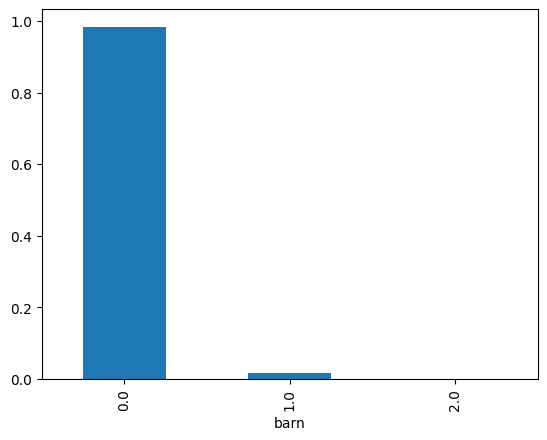

In [59]:
populasjon_2113_1_5.loc[lambda x: x.alder == 20].barn.value_counts(normalize=True).sort_index().plot(kind="bar")

<Axes: xlabel='barn'>

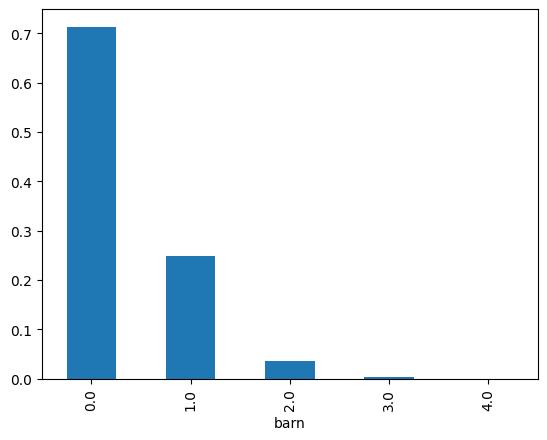

In [60]:
populasjon_2113_1_5.loc[lambda x: x.alder == 27].barn.value_counts(normalize=True).sort_index().plot(kind="bar")

<Axes: xlabel='barn'>

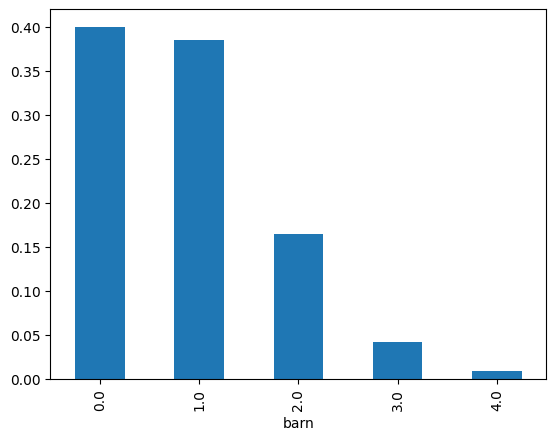

In [61]:
populasjon_2113_1_5.loc[lambda x: x.alder == 32].barn.value_counts(normalize=True).sort_index().plot(kind="bar")

<Axes: xlabel='barn'>

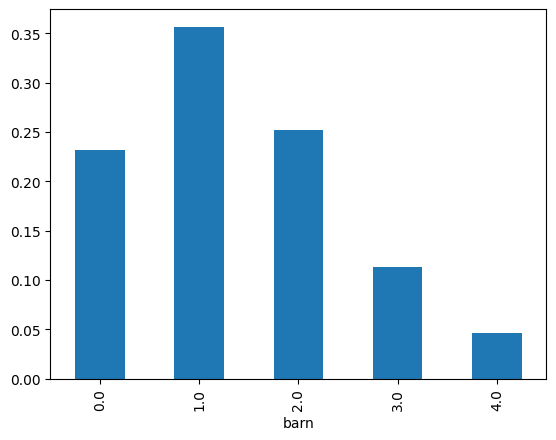

In [62]:
populasjon_2113_1_5.loc[lambda x: x.alder == 45].barn.value_counts(normalize=True).sort_index().plot(kind="bar")

In [80]:
kvinne_45_2025 = pd.read_csv("data_barnefordeling/45_Kvinnen.csv")

In [81]:
kvinne_45_2025

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1935,"9,6","10,4","30,4","27,4","22,2","2,42",Kvinnen,45
1,1940,"9,5","10,1","33,7","29,1","17,6","2,35",Kvinnen,45
2,1945,"9,0","11,8","41,5","26,4","11,3","2,19",Kvinnen,45
3,1950,"9,4","13,3","45,4","23,5","8,4","2,08",Kvinnen,45
4,1955,"11,2","14,3","42,1","24,2","8,1","2,04",Kvinnen,45
5,1960,"11,9","13,8","39,4","25,6","9,2","2,10",Kvinnen,45
6,1965,"12,5","14,2","40,2","24,7","8,4","2,06",Kvinnen,45
7,1970,"13,4","14,7","41,2","23,1","7,6","2,00",Kvinnen,45
8,1975,"14,2","15,3","41,7","21,8","7,0","1,96",Kvinnen,45
9,1979,"15,4","16,4","41,6","20,1","6,5","1,89",Kvinnen,45


In [82]:
pensjonister_u_2_b = populasjon_2113_1_5.loc[lambda x: (x.alder > 67)  & (x.barn < 2)].sex.count()
pensjonister_u_2_b

np.int64(559348)

In [83]:
pensjonister_o_2_b = populasjon_2113_1_5.loc[lambda x: (x.alder > 67)  & (x.barn >= 2)].sex.count()
pensjonister_o_2_b

np.int64(1150323)

In [84]:
arbeids_alder = populasjon_2113_2_1.loc[lambda x: (x.alder > 20) & (x.alder < 67)].sex.count()

In [85]:
arbeids_alder / (pensjonister_o_2_b + pensjonister_u_2_b)

np.float64(1.7901198534688838)

In [86]:
arbeids_alder / pensjonister_o_2_b

np.float64(2.6605709874530894)

In [87]:
arbeids_alder / pensjonister_u_2_b

np.float64(5.471577622517645)

In [88]:
pop = pd.read_csv(data / 'popfordeling_2023-2123_tfr1_5.csv').iloc[:,:93]
pop

,sex,alder,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,...,pop_2104,pop_2105,pop_2106,pop_2107,pop_2108,pop_2109,pop_2110,pop_2111,pop_2112,pop_2113
0,K,0,25310.0,27008.0,26824.0,26391.0,26238.0,25905.0,25543.0,25220.0,...,12693.0,12531.0,12468.0,12327.0,12159.0,12068.0,11961.0,11806.0,11634.0,11689.0
1,K,1,28037.0,25308.0,27004.0,26822.0,26390.0,26236.0,25900.0,25536.0,...,12746.0,12692.0,12531.0,12468.0,12327.0,12159.0,12068.0,11961.0,11806.0,11634.0
2,K,2,26820.0,28032.0,25303.0,26996.0,26817.0,26390.0,26235.0,25896.0,...,12910.0,12746.0,12692.0,12531.0,12468.0,12327.0,12159.0,12067.0,11960.0,11806.0
3,K,3,27466.0,26814.0,28030.0,25300.0,26994.0,26815.0,26385.0,26230.0,...,12963.0,12910.0,12746.0,12692.0,12531.0,12467.0,12327.0,12159.0,12066.0,11960.0
4,K,4,27692.0,27464.0,26811.0,28021.0,25297.0,26991.0,26814.0,26382.0,...,13014.0,12963.0,12910.0,12746.0,12691.0,12531.0,12467.0,12327.0,12159.0,12065.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,28.0,NaN,4.0,2.0,NaN,NaN,1.0,NaN,...,14.0,11.0,8.0,7.0,5.0,11.0,9.0,14.0,16.0,13.0
216,M,106,NaN,8.0,NaN,2.0,1.0,NaN,NaN,NaN,...,7.0,8.0,3.0,1.0,4.0,2.0,3.0,2.0,7.0,6.0
217,M,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,4.0,1.0,NaN,1.0,NaN,NaN,1.0,3.0
218,M,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
pop_2 = pd.read_csv(data / 'popfordeling_2063-2113_tfr1_5.csv')
pop_2

,sex,alder,pop_2023,pop_2064,pop_2065,pop_2066,pop_2067,pop_2068,pop_2069,pop_2070,...,pop_2104,pop_2105,pop_2106,pop_2107,pop_2108,pop_2109,pop_2110,pop_2111,pop_2112,pop_2113
0,K,0,18502.0,18350.0,18164.0,18086.0,18002.0,17751.0,17792.0,17720.0,...,12650.0,12513.0,12346.0,12337.0,12147.0,12127.0,11936.0,11928.0,11647.0,11608.0
1,K,1,18768.0,18502.0,18350.0,18164.0,18085.0,18001.0,17751.0,17791.0,...,12698.0,12650.0,12512.0,12346.0,12337.0,12147.0,12127.0,11936.0,11928.0,11647.0
2,K,2,18734.0,18768.0,18502.0,18349.0,18162.0,18084.0,18001.0,17750.0,...,12868.0,12697.0,12648.0,12512.0,12346.0,12337.0,12147.0,12126.0,11936.0,11927.0
3,K,3,19065.0,18732.0,18766.0,18501.0,18348.0,18162.0,18084.0,18001.0,...,13018.0,12868.0,12697.0,12648.0,12511.0,12345.0,12337.0,12147.0,12126.0,11936.0
4,K,4,19182.0,19064.0,18730.0,18766.0,18501.0,18346.0,18162.0,18084.0,...,13134.0,13016.0,12868.0,12697.0,12648.0,12511.0,12345.0,12337.0,12147.0,12126.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,M,105,4.0,3.0,6.0,5.0,8.0,6.0,7.0,5.0,...,7.0,7.0,6.0,11.0,7.0,5.0,8.0,11.0,6.0,11.0
216,M,106,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2.0,...,2.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0
217,M,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN
218,M,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
pop = pop[["sex","alder", "pop_2023", "pop_2113"]]
pop

,sex,alder,pop_2023,pop_2113
0,K,0,25310.0,11689.0
1,K,1,28037.0,11634.0
2,K,2,26820.0,11806.0
3,K,3,27466.0,11960.0
4,K,4,27692.0,12065.0
...,...,...,...,...
215,M,105,28.0,13.0
216,M,106,NaN,6.0
217,M,107,NaN,3.0
218,M,108,NaN,NaN


In [91]:
pop_2 = pop_2[["sex","alder", "pop_2113"]]
pop

,sex,alder,pop_2023,pop_2113
0,K,0,25310.0,11689.0
1,K,1,28037.0,11634.0
2,K,2,26820.0,11806.0
3,K,3,27466.0,11960.0
4,K,4,27692.0,12065.0
...,...,...,...,...
215,M,105,28.0,13.0
216,M,106,NaN,6.0
217,M,107,NaN,3.0
218,M,108,NaN,NaN


In [92]:
pop = pop.groupby("alder")[["pop_2023", "pop_2113"]].sum()
pop_2 = pop_2.groupby("alder")[["pop_2113"]].sum()

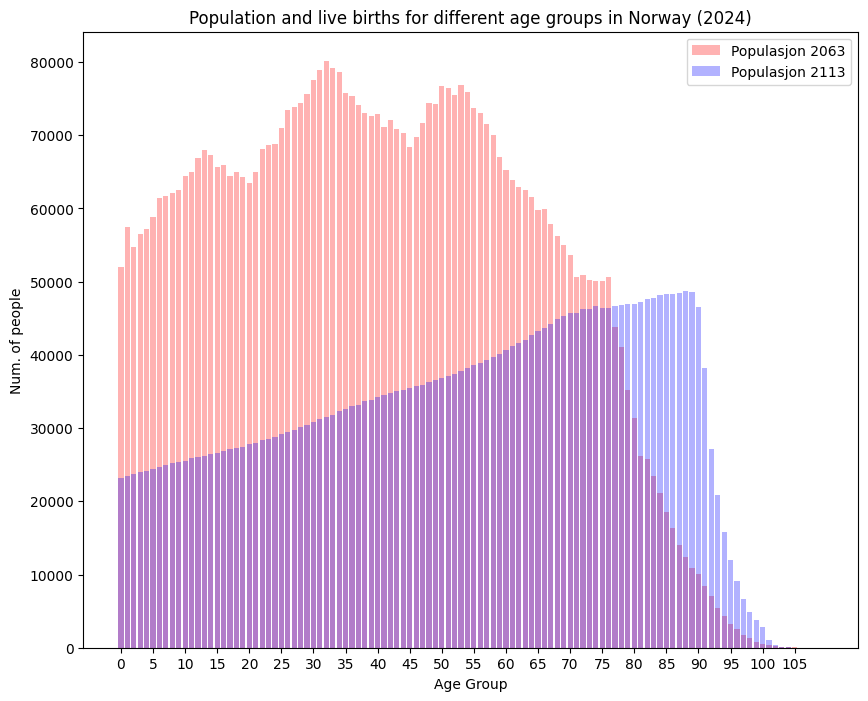

In [93]:
df = pop

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))


ax.bar(pop.index, pop['pop_2023'], color='red', alpha = 0.3, label='Populasjon 2063')
ax.bar(pop.index, pop['pop_2113'], color='blue', alpha = 0.3, label='Populasjon 2113')
# ax.barh(kvinner['alder'], -kvinner['2024'], color='orangered', label='Women')

ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(df.index),5))
ax.set_xticklabels(range(0,len(df.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

In [94]:
populasjon_2113_1_5

,sex,alder,barn
0,M,35.0,2.0
1,M,35.0,3.0
2,M,35.0,0.0
3,M,35.0,0.0
4,M,35.0,2.0
...,...,...,...
5484460,K,0.0,0.0
5484461,M,0.0,0.0
5484462,K,0.0,0.0
5484463,M,0.0,0.0


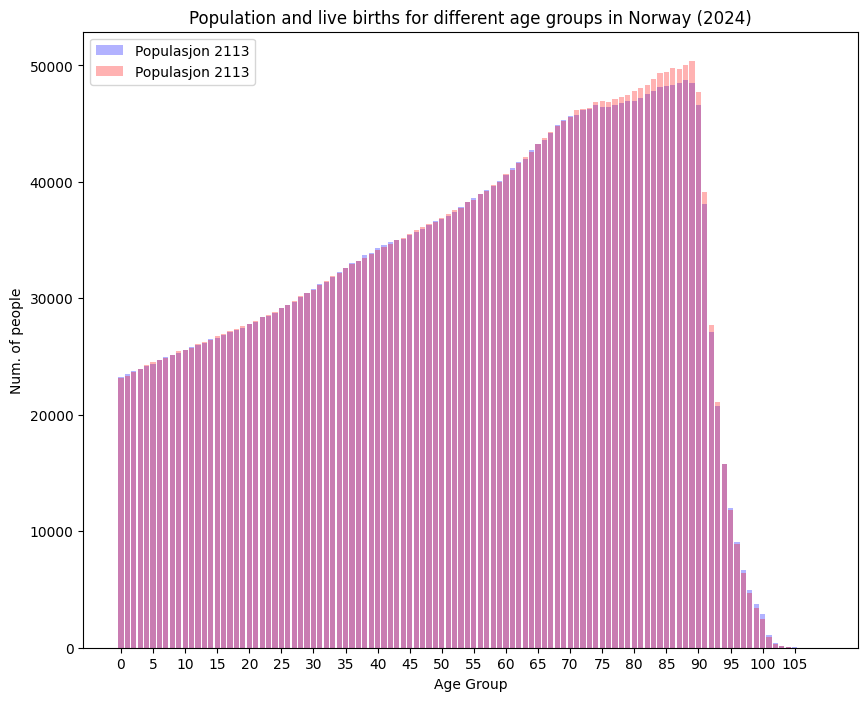

In [95]:
df = pop

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))


#ax.bar(pop.index, pop['pop_2023'], color='red', alpha = 0.3, label='Populasjon 2063')
ax.bar(pop.index, pop['pop_2113'], color='blue', alpha = 0.3, label='Populasjon 2113')
ax.bar(pop_2.index, pop_2['pop_2113'], color='red', alpha = 0.3, label='Populasjon 2113')
# ax.barh(kvinner['alder'], -kvinner['2024'], color='orangered', label='Women')

ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(df.index),5))
ax.set_xticklabels(range(0,len(df.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

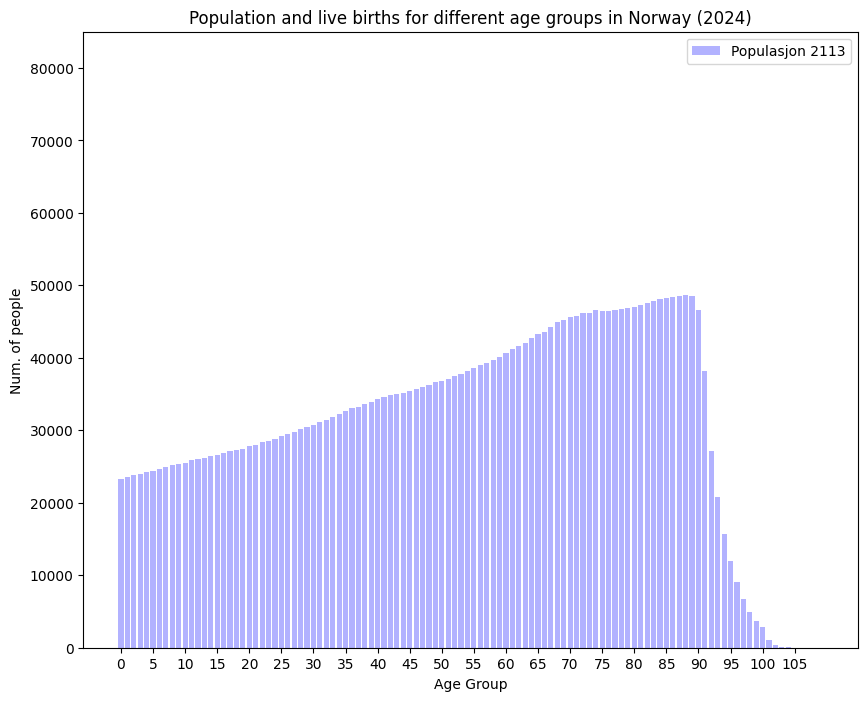

In [96]:
df = pop

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))


#ax.bar(pop.index, pop['pop_2023'], color='red', alpha = 0.3, label='Populasjon 2063')
ax.bar(pop.index, pop['pop_2113'], color='blue', alpha = 0.3, label='Populasjon 2113')
# ax.barh(kvinner['alder'], -kvinner['2024'], color='orangered', label='Women')

ax.set_ylim(0, 85e3)
ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(df.index),5))
ax.set_xticklabels(range(0,len(df.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

In [97]:
pop = pop.reset_index()
pop

,alder,pop_2023,pop_2113
0,0,51991.0,23222.0
1,1,57415.0,23512.0
2,2,54778.0,23791.0
3,3,56455.0,23941.0
4,4,57146.0,24184.0
...,...,...,...
105,105,104.0,25.0
106,106,0.0,10.0
107,107,0.0,4.0
108,108,0.0,0.0


In [98]:
bins = list(range(0, 114, 5))

# Lag bins og gi dem lesbare etiketter
pop["aldersgruppe"] = pd.cut(pop["alder"], bins=bins, right=False, include_lowest=True,
                    labels=[f"{i}-{i+4}" for i in range(0, 109, 5)])



In [99]:
år = 2063

fremskrivning_2 = pd.read_csv(data / f"utvikling_{år}.csv").rename(columns={"0":"2.1"})

fremskrivning_2["år"] = range(år, år+ len(fremskrivning_2))
fremskrivning_2

FileNotFoundError: [Errno 2] No such file or directory: 'data/utvikling_2063.csv'

In [105]:
import altair as alt
import pandas as pd
from pathlib import Path

# Load data
data_path = Path("data") / "popfordeling_2023-2058_tfr1_5.csv"
pop = pd.read_csv(data_path)

# Create age bins (10-year intervals)
bins = list(range(0, 110, 10)) + [200]
labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] + ["100+"]
pop['alder_bins'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
grouped_data = pop.groupby("alder_bins", observed=False)[["pop_2023", "pop_2058"]].sum().reset_index()

# 1. Dumbbell Plot
melted_data = grouped_data.melt(id_vars=['alder_bins'], var_name='year', value_name='population')
melted_data = melted_data.loc[lambda x: x['alder_bins'] != '100+']
age_order = labels 

In [111]:
melted_data["year"] = melted_data["year"].str.replace("pop_", "")

In [117]:


base = alt.Chart(melted_data).encode(
    y=alt.Y('alder_bins:N', sort=age_order, title='Age Brackets')
)

# Layer for the connecting lines
lines = base.mark_line().encode(
    x=alt.X('population:Q', title='Population'),
    detail='alder_bins:N', # Group lines by age bracket
    color=alt.value('lightgray') # Set a neutral color for the lines
)

# Layer for the points
points = base.mark_point(size=100, filled=True).encode(
    x=alt.X('population:Q'),
    color=alt.Color('year:N', title='Year'), # Color points by year
    tooltip=['alder_bins', 'year', 'population']
)

dumbbell = (lines + points).properties(
    title='Population Shift (Dumbbell Plot)',
    width=600,
    height=400
).interactive()
dumbbell

alt.LayerChart(...)

In [107]:
# 3. Difference Chart
grouped_data['diff'] = grouped_data['pop_2058'] - grouped_data['pop_2023']
grouped_data['change_type'] = grouped_data['diff'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

diff_chart = alt.Chart(grouped_data).mark_bar().encode(
    x=alt.X('diff:Q', title='Change in Population (2058 - 2023)'),
    y=alt.Y('alder_bins:N', sort=age_order, title='Age Brackets'),
    color=alt.Color('change_type:N', scale=alt.Scale(domain=['Increase', 'Decrease'], range=['green', 'red']), title='Change Type'),
    tooltip=['alder_bins', 'diff']
).properties(
    title='Net Population Change by Age Group',
    width=400
).interactive()

# Display both
(diff_chart)


alt.Chart(...)